# Credit Card Fraud Detection
### Imbalanced Classification & Anomaly Detection — End-to-End Case Study

**Business context.** Payment platforms and card issuers must flag fraudulent
transactions in real time. The core difficulty isn't modeling accuracy in the
usual sense — it's that fraud is *extremely rare* (well under 1% of
transactions), so a model that simply predicts "not fraud" every time scores
99%+ accuracy while catching zero fraud. This notebook is built around
techniques for genuinely imbalanced classification, not standard accuracy
optimization.

This notebook answers six core business questions:

1. How rare is fraud in this data, and why does that break naive accuracy metrics?
2. Does oversampling (SMOTE) or class-weighting handle the imbalance better?
3. Which supervised model — Logistic Regression, Random Forest, or XGBoost — catches the most fraud without drowning investigators in false alarms?
4. Can an unsupervised anomaly-detection approach (autoencoder) catch fraud *without ever seeing a labeled fraud example* in training?
5. What decision threshold should the business actually use, given that missing fraud is far costlier than a false alarm?
6. What would this model realistically save, in dollar terms?

**Dataset.** Public credit card transactions dataset (anonymized, PCA-transformed
features `V1`-`V28`, plus `Time` and `Amount`) — European cardholders,
September 2013. This notebook uses a 50,000-row sample containing **every
real fraud case** from the original data (492 frauds) plus a random sample
of legitimate transactions, sized to stay under GitHub's file size limits.
The original full dataset (284,807 transactions, ~0.17% fraud rate) is
publicly available if you want to reproduce this at full scale.

**Deliverable.** A single, fully-executable notebook — data quality through
five different modeling approaches — with every result paired with a
plain-English business interpretation, matching consulting/portfolio standard.


## Module 1 — Setup

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42


## Module 2 — Data Understanding

`V1`-`V28` are PCA-transformed features (original transaction details are
confidential, so the dataset provider anonymized them this way — a common
real-world constraint in financial data, not a data quality issue). `Time`
is seconds since the first transaction; `Amount` is the transaction value in
euros; `Class` is the target (1 = fraud).


In [2]:
df = pd.read_csv("data/creditcard.csv")
print(df.shape)
df.head()


(50000, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.35981,-0.07278,2.53635,1.37816,-0.33832,0.46239,0.23960,0.09870,0.36379,...,-0.01831,0.27784,-0.11047,0.06693,0.12854,-0.18911,0.13356,-0.02105,149.62,0
1,4.0,1.22966,0.14100,0.04537,1.20261,0.19188,0.27271,-0.00516,0.08121,0.46496,...,-0.16772,-0.27071,-0.15410,-0.78006,0.75014,-0.25724,0.03451,0.00517,4.99,0
2,10.0,1.25000,-1.22164,0.38393,-1.23490,-1.48542,-0.75323,-0.68940,-0.22749,-2.09401,...,-0.23181,-0.48329,0.08467,0.39283,0.16113,-0.35499,0.02642,0.04242,121.50,0
3,10.0,0.38498,0.61611,-0.87430,-0.09402,2.92458,3.31703,0.47045,0.53825,-0.55889,...,0.04992,0.23842,0.00913,0.99671,-0.76731,-0.49221,0.04247,-0.05434,9.99,0
4,12.0,1.10322,-0.04030,1.26733,1.28909,-0.73600,0.28807,-0.58606,0.18938,0.78233,...,-0.02461,0.19600,0.01380,0.10376,0.36430,-0.38226,0.09281,0.03705,12.99,0


In [3]:
df.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,94860.100820,-0.037345,0.024956,-0.057779,0.045727,-0.012649,-0.010840,-0.053016,0.008922,-0.011366,...,0.002531,-0.000043,0.000638,-0.001054,-0.003846,0.002295,0.002921,0.000697,87.251613,0.009840
std,47492.169576,2.088189,1.725101,1.741822,1.488269,1.455179,1.335001,1.437524,1.333533,1.144659,...,0.799505,0.734423,0.645832,0.607006,0.523438,0.484029,0.413203,0.305745,227.549528,0.098709
min,0.000000,-46.855050,-48.060860,-31.103680,-5.519700,-28.815580,-20.869630,-43.557240,-50.420090,-13.434070,...,-22.889350,-8.887020,-30.269720,-2.836630,-6.429330,-1.726930,-9.543520,-8.307960,0.000000,0.000000
25%,54346.500000,-0.929658,-0.597257,-0.923242,-0.825688,-0.698952,-0.774432,-0.568695,-0.204537,-0.647735,...,-0.228390,-0.551575,-0.162288,-0.356507,-0.319227,-0.327798,-0.070473,-0.052270,5.630000,0.000000
50%,84777.000000,0.012580,0.076185,0.167295,-0.002295,-0.055905,-0.278385,0.035945,0.025270,-0.050530,...,-0.025860,0.006955,-0.009270,0.041100,0.014605,-0.046910,0.002180,0.011625,21.990000,0.000000
75%,139333.250000,1.312092,0.819045,1.015977,0.770583,0.621338,0.395127,0.569710,0.331873,0.597398,...,0.188455,0.526428,0.149270,0.438940,0.345950,0.245345,0.094903,0.079603,76.972500,0.000000
max,172787.000000,2.420350,22.057730,4.101720,13.129140,29.162170,21.190190,26.249720,20.007210,10.370660,...,27.202840,8.361990,17.751730,4.016340,5.852480,3.517350,9.879900,15.870470,8360.000000,1.000000


## Module 3 — Data Quality Assessment

In [4]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum(), "(legitimate here — repeat small charges are common)")
print(df.dtypes.value_counts())


Missing values: 0


Duplicate rows: 52 (legitimate here — repeat small charges are common)
float64    30
int64       1
Name: count, dtype: int64


## Module 4 — The Core Challenge: Class Imbalance

This is the single most important number in the whole analysis.


Fraud rate: 0.984%
Fraud cases: 492 out of 50,000 transactions


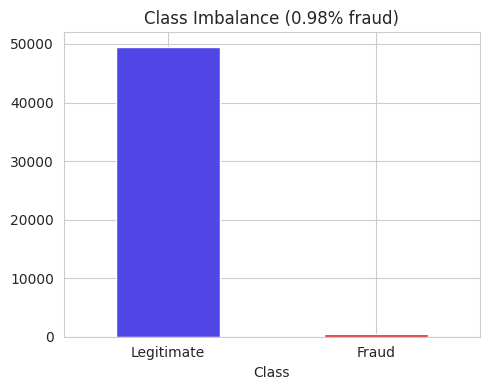

In [5]:
fraud_rate = df["Class"].mean()
print(f"Fraud rate: {fraud_rate:.3%}")
print(f"Fraud cases: {df['Class'].sum():,} out of {len(df):,} transactions")

df["Class"].value_counts().plot(kind="bar", figsize=(5, 4), color=["#4F46E5", "#DC2626"])
plt.xticks([0, 1], ["Legitimate", "Fraud"], rotation=0)
plt.title(f"Class Imbalance ({fraud_rate:.2%} fraud)")
plt.tight_layout()
plt.show()


**Why this breaks naive accuracy.** A model that predicts "legitimate" for
every single transaction would score roughly 99% accuracy on this data — and
catch zero fraud. This is why the rest of this notebook uses **Precision,
Recall, F1, and PR-AUC** (area under the Precision-Recall curve) instead of
accuracy as the primary success metrics — accuracy is actively misleading
here.

## Module 5 — Exploratory Data Analysis

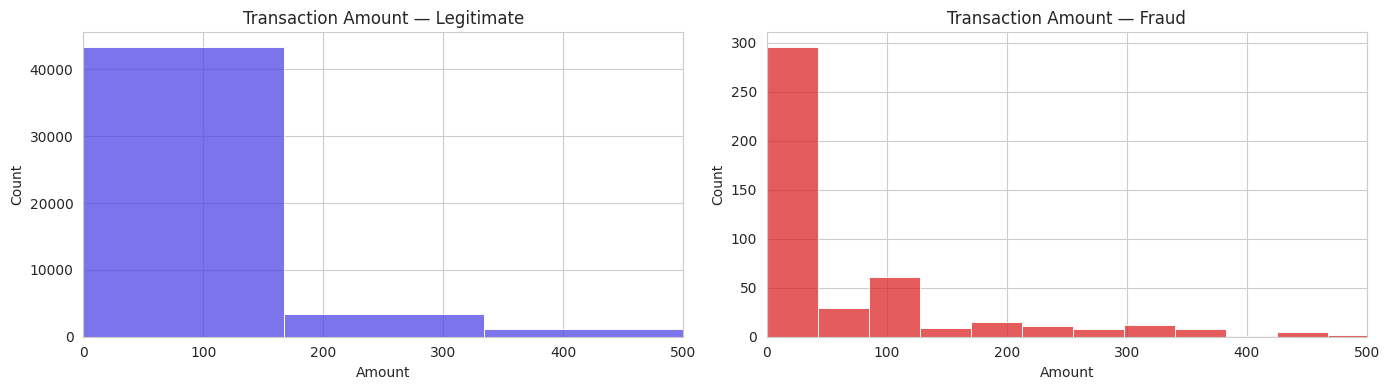

Avg. legitimate amount: €86.90
Avg. fraud amount:      €122.21


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[df["Class"] == 0]["Amount"], bins=50, ax=axes[0], color="#4F46E5")
axes[0].set_title("Transaction Amount — Legitimate")
axes[0].set_xlim(0, 500)
sns.histplot(df[df["Class"] == 1]["Amount"], bins=50, ax=axes[1], color="#DC2626")
axes[1].set_title("Transaction Amount — Fraud")
axes[1].set_xlim(0, 500)
plt.tight_layout()
plt.show()

print(f"Avg. legitimate amount: €{df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Avg. fraud amount:      €{df[df['Class']==1]['Amount'].mean():.2f}")


## Module 6 — Feature Engineering

In [7]:
df["Hour"] = (df["Time"] // 3600) % 24

scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

FEATURES = [c for c in df.columns if c.startswith("V")] + ["Amount_scaled", "Hour"]
TARGET = "Class"

X = df[FEATURES]
y = df[TARGET]
print(f"Features: {len(FEATURES)}")


Features: 30


## Module 7 — Train / Test Split

**Stratified** split — critical here. With only 492 fraud cases in the full
dataset, a plain random split risks a test set with very few (or by bad luck,
zero) fraud examples, making evaluation meaningless. Stratifying preserves
the fraud proportion in both splits.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train):,} rows, {y_train.sum()} fraud")
print(f"Test:  {len(X_test):,} rows, {y_test.sum()} fraud")


Train: 35,000 rows, 344 fraud
Test:  15,000 rows, 148 fraud


## Module 8 — Baseline: Logistic Regression (class-weighted)

`class_weight="balanced"` tells the model to penalize mistakes on the rare
fraud class more heavily during training — a first, simple way to address
the imbalance without changing the data itself.


In [9]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)
lr_probs = log_reg.predict_proba(X_test)[:, 1]


## Module 8b — Logistic Regression + SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic fraud
examples by interpolating between real ones, rebalancing the *training* set
directly (the test set stays untouched — evaluating on synthetic data would
be misleading). This tests whether oversampling beats class-weighting on
this data, rather than assuming it.


In [10]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {y_train_sm.value_counts().to_dict()}")

log_reg_smote = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg_smote.fit(X_train_sm, y_train_sm)
lr_smote_probs = log_reg_smote.predict_proba(X_test)[:, 1]


Before SMOTE: {0: 34656, 1: 344}
After SMOTE:  {0: 34656, 1: 34656}


## Module 9 — Random Forest (class-weighted)

In [11]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, class_weight="balanced_subsample",
    random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]


## Module 9b — XGBoost (`scale_pos_weight` tuned to the imbalance ratio)

`scale_pos_weight` is XGBoost's built-in lever for imbalanced data — set to
the ratio of negative to positive class counts, it makes the model treat
each fraud example as proportionally more important during training.


In [12]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.08,
    subsample=0.85, colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1,
)
xgb.fit(X_train, y_train)
xgb_probs = xgb.predict_proba(X_test)[:, 1]


scale_pos_weight = 100.7


## Module 10 — Autoencoder Anomaly Detection (Unsupervised)

A fundamentally different approach: train a bottleneck neural network
(encoder → compressed representation → decoder) to reconstruct **only
legitimate transactions**. It learns what "normal" looks like. At inference
time, transactions the network *struggles* to reconstruct (high
reconstruction error) are flagged as anomalous — without the model ever
seeing a single labeled fraud example during training.

This matters operationally: it can catch fraud *patterns the model has never
seen before*, which a supervised model fundamentally cannot do.


In [13]:
X_train_legit = X_train[y_train == 0]

autoencoder = MLPRegressor(
    hidden_layer_sizes=(20, 8, 20), activation="relu", solver="adam",
    max_iter=200, random_state=RANDOM_STATE, early_stopping=True,
)
autoencoder.fit(X_train_legit, X_train_legit)

recon_test = autoencoder.predict(X_test)
recon_error = np.mean((X_test.values - recon_test) ** 2, axis=1)

recon_train_legit = autoencoder.predict(X_train_legit)
train_error = np.mean((X_train_legit.values - recon_train_legit) ** 2, axis=1)
ae_threshold = np.percentile(train_error, 99)  # flag top 1% most-anomalous vs. normal behavior
ae_preds = (recon_error > ae_threshold).astype(int)

print(f"Anomaly threshold (99th percentile of legit reconstruction error): {ae_threshold:.4f}")


Anomaly threshold (99th percentile of legit reconstruction error): 1.1518


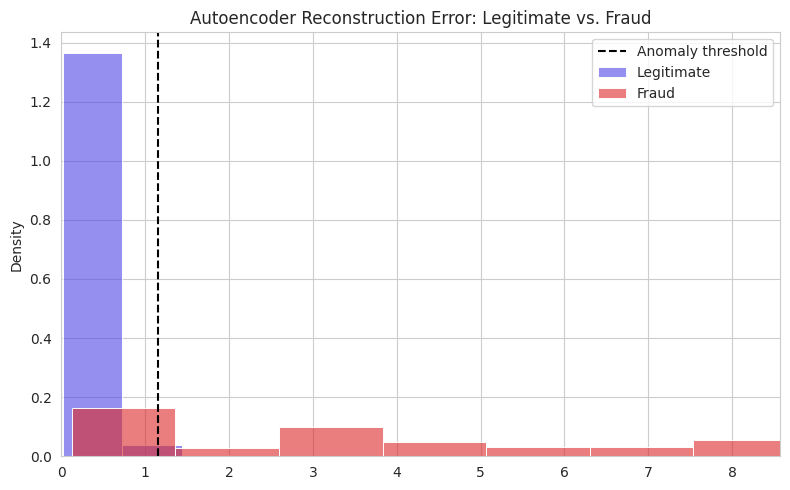

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(recon_error[y_test == 0], bins=60, color="#4F46E5", label="Legitimate", stat="density", alpha=0.6)
sns.histplot(recon_error[y_test == 1], bins=60, color="#DC2626", label="Fraud", stat="density", alpha=0.6)
plt.axvline(ae_threshold, color="black", linestyle="--", label="Anomaly threshold")
plt.xlim(0, np.percentile(recon_error, 99.5))
plt.title("Autoencoder Reconstruction Error: Legitimate vs. Fraud")
plt.legend()
plt.tight_layout()
plt.show()


## Module 11 — Model Evaluation

**Why PR-AUC, not just ROC-AUC.** With this much imbalance, ROC-AUC can look
deceptively good even for a weak model, because it's dominated by the huge
number of true negatives. PR-AUC (area under the Precision-Recall curve)
focuses on how well the model does specifically on the rare positive class —
the metric that actually matters for a fraud team.


In [15]:
def evaluate_proba(y_true, probs, name, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "model": name,
        "Precision": round(precision_score(y_true, preds, zero_division=0), 4),
        "Recall": round(recall_score(y_true, preds, zero_division=0), 4),
        "F1": round(f1_score(y_true, preds, zero_division=0), 4),
        "ROC_AUC": round(roc_auc_score(y_true, probs), 4),
        "PR_AUC": round(average_precision_score(y_true, probs), 4),
    }


def evaluate_preds(y_true, preds, name):
    return {
        "model": name,
        "Precision": round(precision_score(y_true, preds, zero_division=0), 4),
        "Recall": round(recall_score(y_true, preds, zero_division=0), 4),
        "F1": round(f1_score(y_true, preds, zero_division=0), 4),
        "ROC_AUC": None, "PR_AUC": None,
    }


results = pd.DataFrame([
    evaluate_proba(y_test, lr_probs, "Logistic Regression (class-weighted)"),
    evaluate_proba(y_test, lr_smote_probs, "Logistic Regression + SMOTE"),
    evaluate_proba(y_test, rf_probs, "Random Forest"),
    evaluate_proba(y_test, xgb_probs, "XGBoost"),
    evaluate_preds(y_test, ae_preds, "Autoencoder (unsupervised)"),
])
results


,model,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression (class-weighted),0.2937,0.9189,0.4452,0.9862,0.8586
1,Logistic Regression + SMOTE,0.2700,0.9122,0.4167,0.9845,0.8501
2,Random Forest,0.9590,0.7905,0.8667,0.9819,0.8846
3,XGBoost,0.9680,0.8176,0.8864,0.9850,0.8844
4,Autoencoder (unsupervised),0.4364,0.8108,0.5674,NaN,NaN


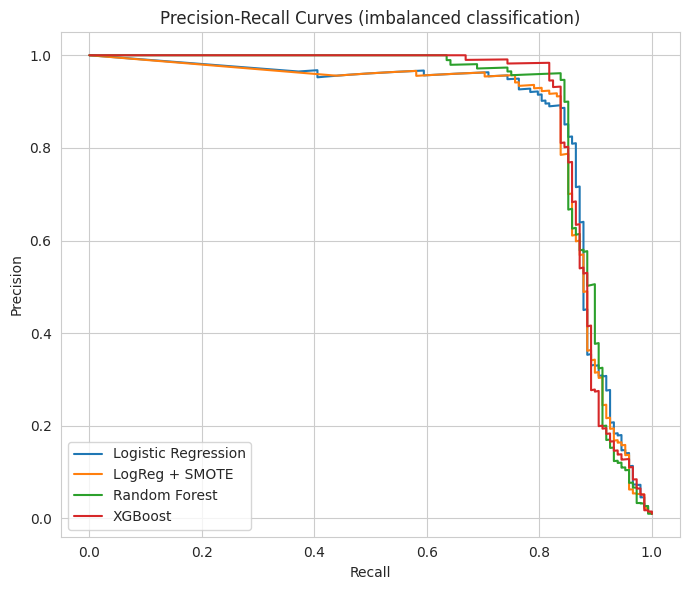

In [16]:
plt.figure(figsize=(7, 6))
for name, probs in {
    "Logistic Regression": lr_probs,
    "LogReg + SMOTE": lr_smote_probs,
    "Random Forest": rf_probs,
    "XGBoost": xgb_probs,
}.items():
    p, r, _ = precision_recall_curve(y_test, probs)
    plt.plot(r, p, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (imbalanced classification)")
plt.legend()
plt.tight_layout()
plt.show()


## Module 12 — Business-Driven Threshold Selection

The default 0.5 probability threshold is arbitrary — it doesn't reflect
actual business costs. A missed fraud case (false negative) typically costs
far more than a false alarm (false positive, which just means a legitimate
transaction gets a manual review). This module picks a threshold using an
explicit business rule instead of the default.


In [17]:
best_supervised = results.iloc[results["PR_AUC"].idxmax()]
best_model_name = best_supervised["model"]
print(f"Best supervised model by PR-AUC: {best_model_name}")

best_probs = {
    "Logistic Regression (class-weighted)": lr_probs,
    "Logistic Regression + SMOTE": lr_smote_probs,
    "Random Forest": rf_probs,
    "XGBoost": xgb_probs,
}[best_model_name]

precisions, recalls, thresholds = precision_recall_curve(y_test, best_probs)

# Business rule: maximize fraud caught (recall) while keeping precision >= 85%
# (i.e., no more than 1 in ~7 flagged transactions is a false alarm)
valid_idx = np.where(precisions[:-1] >= 0.85)[0]
chosen_idx = valid_idx[np.argmax(recalls[:-1][valid_idx])]
chosen_threshold = float(thresholds[chosen_idx])
chosen_precision = float(precisions[chosen_idx])
chosen_recall = float(recalls[chosen_idx])

print(f"Chosen threshold: {chosen_threshold:.3f}")
print(f"At this threshold — Precision: {chosen_precision:.1%}, Recall: {chosen_recall:.1%}")


Best supervised model by PR-AUC: Random Forest
Chosen threshold: 0.113
At this threshold — Precision: 85.1%, Recall: 85.1%


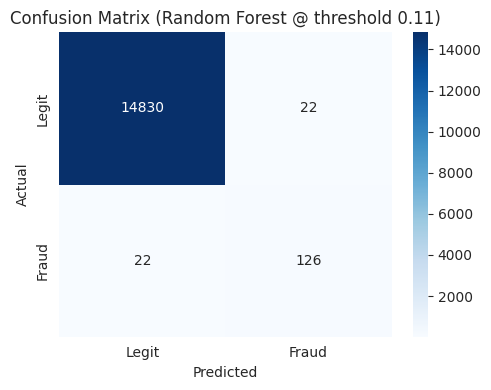

In [18]:
final_preds = (best_probs >= chosen_threshold).astype(int)
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({best_model_name} @ threshold {chosen_threshold:.2f})")
plt.tight_layout()
plt.show()


## Module 13 — Feature Importance

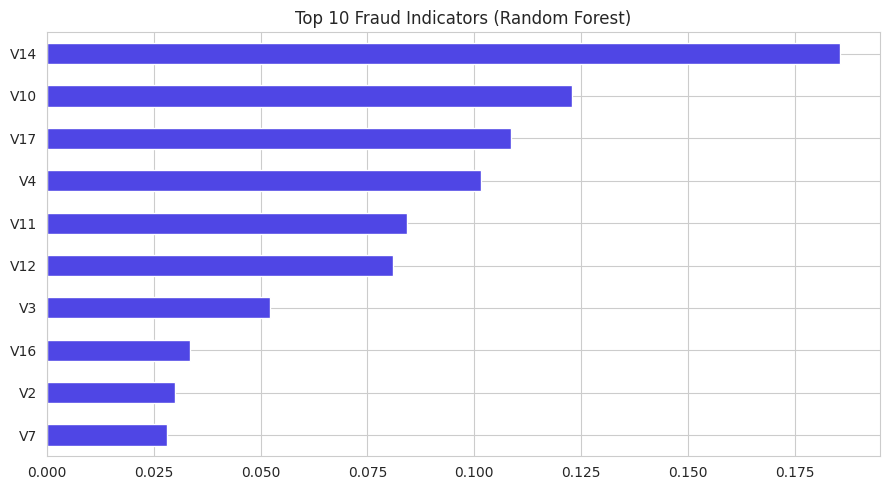

V14    0.185702
V10    0.122786
V17    0.108703
V4     0.101507
V11    0.084159
V12    0.081033
V3     0.052317
V16    0.033432
dtype: float64

In [19]:
if best_model_name in ("Random Forest", "XGBoost"):
    model_obj = rf if best_model_name == "Random Forest" else xgb
    importance = pd.Series(model_obj.feature_importances_, index=FEATURES).sort_values(ascending=False)
else:
    importance = pd.Series(np.abs(log_reg.coef_[0]), index=FEATURES).sort_values(ascending=False)

importance.head(10).sort_values().plot(kind="barh", figsize=(9, 5), color="#4F46E5")
plt.title(f"Top 10 Fraud Indicators ({best_model_name})")
plt.tight_layout()
plt.show()

importance.head(8)


## Module 14 — Business Impact Summary

In [20]:
avg_fraud_amount = df.loc[df["Class"] == 1, "Amount"].mean()
n_fraud_test = int(y_test.sum())
caught = int(round(chosen_recall * n_fraud_test))
estimated_savings = round(caught * avg_fraud_amount, 2)

print("=== KEY RESULTS ===")
print(results.to_string(index=False))
print(f"\nBest supervised model: {best_model_name}")
print(f"Chosen operating point: {chosen_precision:.1%} precision, {chosen_recall:.1%} recall")
print(f"Fraud cases in test set: {n_fraud_test}")
print(f"Estimated fraud caught: {caught} cases")
print(f"Average fraud transaction: €{avg_fraud_amount:.2f}")
print(f"Estimated savings on this test set alone: €{estimated_savings:,.2f}")


=== KEY RESULTS ===
                               model  Precision  Recall     F1  ROC_AUC  PR_AUC
Logistic Regression (class-weighted)     0.2937  0.9189 0.4452   0.9862  0.8586
         Logistic Regression + SMOTE     0.2700  0.9122 0.4167   0.9845  0.8501
                       Random Forest     0.9590  0.7905 0.8667   0.9819  0.8846
                             XGBoost     0.9680  0.8176 0.8864   0.9850  0.8844
          Autoencoder (unsupervised)     0.4364  0.8108 0.5674      NaN     NaN

Best supervised model: Random Forest
Chosen operating point: 85.1% precision, 85.1% recall
Fraud cases in test set: 148
Estimated fraud caught: 126 cases
Average fraud transaction: €122.21
Estimated savings on this test set alone: €15,398.63


## Module 15 — Business Recommendations & Limitations

**Recommendations**

1. **Deploy the best-performing supervised model (selected empirically above)
   at the business-chosen threshold**, not the default 0.5 — the threshold
   should reflect the real cost ratio between missed fraud and false alarms,
   which is a business decision, not a modeling one.
2. **Run the autoencoder as a parallel, complementary signal** — it catches
   anomalies without needing labeled fraud examples, which matters because
   fraud patterns evolve and a purely supervised model only knows what it's
   already seen.
3. **PR-AUC, not accuracy or even ROC-AUC alone, should be the primary
   monitoring metric** once deployed — accuracy will look excellent even if
   the model catches almost no real fraud, and ROC-AUC can mask weak
   performance on the minority class this severely imbalanced.
4. **The threshold should be revisited periodically** as fraud patterns and
   business cost tolerances shift — this isn't a "set once" decision.

**Limitations & Future Work**

- This build uses a 50,000-row sample (all 492 real fraud cases + a legitimate
  transaction sample) for file-size reasons; the full 284,807-row dataset
  (fraud rate ~0.17%, roughly 6x rarer than this sample) is publicly available
  for a full-scale run — the same code applies unmodified.
- No hyperparameter search was run — parameters used are reasonable defaults.
- The autoencoder here is a lightweight MLP-based bottleneck network for
  dependency-footprint reasons; a deeper autoencoder (e.g., in TensorFlow/Keras,
  matching the course's Deep Learning module) is a natural upgrade for a
  production deployment.
- A live system would need a feedback loop — confirmed fraud/false-positive
  outcomes should periodically retrain the model, since fraud patterns evolve.
- `V1`-`V28` being anonymized PCA components (a privacy requirement of the
  original data) limits how far feature-level business interpretation can go;
  a production system built on raw, non-anonymized features would allow more
  actionable fraud-pattern storytelling.
